In [2]:
import os
# os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
# os.environ['CUDA_VISIBLE_DEVICES'] = '1'
os.environ['JAX_PLATFORMS'] = 'cpu'
# os.environ['JAX_LOG_COMPILES'] = '1'
# os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
# os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.6'

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
# test_projection.py
from agent_system.environments.env_package.craftext import craftext_projection, INVALID_ACTION_ID

# Список тестовых выводов от "LLM"
test_actions = [
    "<think>I should go left.</think><action>left</action>",             # Идеальный случай
    "<think>I will try to place a table.</think><action>place table</action>", # Другой идеальный случай
    "<action>up</action>",                                               # Случай без <think>
    "<think>Let's move right.</think>",                                   # Случай без <action>
    "<think>I am confused.</think><action>fly to the moon</action>",    # Невалидное действие
    "<think>你好</think><action>down</action>",                           # Случай с мусором (китайский)
]

processed_actions, valids = craftext_projection(test_actions)

print(f"Processed Actions: {processed_actions}")
print(f"Valids: {valids}")

# Проверки (ассерты)
assert processed_actions == [1, 8, INVALID_ACTION_ID, INVALID_ACTION_ID, INVALID_ACTION_ID, INVALID_ACTION_ID]
assert valids == [1, 1, 0, 0, 0, 0]

print("\nТест проекции прошел успешно!")

In [ ]:
from agent_system.environments.env_package.craftext import CraftextWorker

print("Инициализация воркера...")
# Инициализируем воркер напрямую, как обычный Python-объект
worker = CraftextWorker(seed=42, env_kwargs={})

print("\nТестируем reset()...")
obs, info = worker.reset(scenario_idx=5)

print(f"  - Тип observation: {type(obs)}")
print(f"  - Форма observation: {obs.shape}")
print(f"  - Ключи в info: {info.keys()}")
assert 'text_render' in info
assert 'instruction' in info
print("  - Инструкция:", info['instruction'][:50] + "...") # Печатаем начало инструкции
print("  - Текстовый рендер:", info['text_render'][:70] + "...") # Печатаем начало рендера

print("\nТестируем step()...")
# Действие "RIGHT" (ID=2)
obs, reward, done, info = worker.step(action=2)

print(f"  - Тип reward: {type(reward)}")
print(f"  - Тип done: {type(done)}")
print(f"  - Ключи в info: {info.keys()}")
assert 'text_render' in info
assert 'instruction' in info
print(f"  - Награда: {reward}, Завершено: {done}")

print("\nТесты воркера прошли успешно!")

In [ ]:
import ray

from agent_system.environments.env_package.craftext import build_craftext_envs

ray.shutdown()

ray.init()

print("Создаем векторизованную среду...")
# Используем маленькие значения для теста
env_num = 2
group_n = 2
total_workers = env_num * group_n

env = build_craftext_envs(
    seed=0,
    env_num=env_num,
    group_n=group_n,
    resources_per_worker={'num_cpus': 1},
    is_train=True,
)

print(f"\nТестируем reset() на {total_workers} воркерах...")
obs_list, info_list = env.reset()

print(f"  - Длина списка obs: {len(obs_list)}")
print(f"  - Длина списка info: {len(info_list)}")
assert len(obs_list) == total_workers
assert len(info_list) == total_workers
print("  - Ключи в первом info:", info_list[0].keys())

print(f"\nТестируем step() на {total_workers} воркерах...")
# Отправляем 4 случайных действия
actions = [1, 2, 3, 4]
obs_list, reward_list, done_list, info_list = env.step(actions)

print(f"  - Длина списка rewards: {len(reward_list)}")
assert len(reward_list) == total_workers
print("  - Награды:", reward_list)

print("\nЗакрываем среду...")
env.close()
ray.shutdown()

print("\nИнтеграционный тест прошел успешно!")

In [ ]:
ray.shutdown()

In [ ]:
# profile_worker.py
import time
import os
import yaml
import psutil # Установите, если нет: pip install psutil
from agent_system.environments.env_package.alfworld.envs import AlfworldWorker
from agent_system.environments.env_package.alfworld.alfworld.agents.environment.alfred_tw_env import AlfredTWEnv

# Функция для отслеживания памяти
def print_memory_usage(process):
    mem_info = process.memory_info()
    print(f"RAM Usage: {mem_info.rss / 1024 / 1024:.2f} MB")

# --- Основной код ---
alf_config_path = os.path.join('../agent_system/environments/env_package/alfworld/configs/config_tw.yaml')
with open(alf_config_path) as reader:
    config = yaml.safe_load(reader)
base_env = AlfredTWEnv()

worker = AlfworldWorker(config={}, seed=0, base_env=base_env)
process = psutil.Process(os.getpid())

print("--- Initial Memory ---")
print_memory_usage(process)

print("\n--- Running 10 Episodes ---")
for i in range(10):
    print(f"\nEpisode {i+1}")
    obs, info = worker.reset(scenario_idx=0)
    done = False
    step = 0
    while not done and step < 100: # Ограничим длину эпизода для теста
        obs, reward, done, info = worker.step(action=2) # Просто идем вправо
        step += 1
    
    print(f"Episode finished. Current memory:")
    print_memory_usage(process)
    time.sleep(1)

print("\n--- Profiling Finished ---")

In [ ]:
# profile_base_craftext_wrapper.py
# Test memory usage of the base InstructionWrapper (CraftextWrapper) directly
import time
import os
import gc
import psutil
import jax
import jax.numpy as jnp
from craftax.craftax_env import make_craftax_env_from_name
from craftext.enviroment.craftext_wrapper import InstructionWrapper
from craftext.enviroment.encoders.craftext_base_model_encoder import EncodeForm
from craftext.enviroment.encoders.craftext_distilbert_model_encoder import DistilBertEncode
from craftext.enviroment.scenarious.manager import ScenariosNoLambda

# Функция для отслеживания памяти
def print_memory_usage(process):
    mem_info = process.memory_info()
    print(f"RAM Usage: {mem_info.rss / 1024 / 1024:.2f} MB")

# --- Основной код ---
print("Initializing base Craftext environment and wrapper...")

# Create base craftax environment
env = make_craftax_env_from_name("Craftax-Classic-Pixels-v1", auto_reset=False)

# Create InstructionWrapper (the base CraftextWrapper)
wrapper = InstructionWrapper(
    env=env,
    config_name='achievements_collect_wood',
    sample_range=[0, 10_000],
    scenario_handler_class=ScenariosNoLambda,
    encode_model_class=DistilBertEncode,
    encode_form=EncodeForm.EMBEDDING
)

# Get environment parameters
env_params = wrapper.env.default_params

# Initialize JAX RNG key
key = jax.random.PRNGKey(0)
state = None

process = psutil.Process(os.getpid())

print("\n--- Initial Memory ---")
print_memory_usage(process)

print("\n--- Running 10 Episodes (Base InstructionWrapper) ---")
for i in range(10):
    print(f"\nEpisode {i+1}")
    
    # Reset: wrapper.reset(_rng, env_params, instruction_idx)
    key, reset_key = jax.random.split(key)
    obs_jax, state = wrapper.reset(reset_key, env_params, instruction_idx=0)
    
    done = False
    step = 0
    while not done and step < 100:  # Ограничим длину эпизода для теста
        # Step: wrapper.step(_rng, env_state, action, env_params)
        key, step_key = jax.random.split(key)
        obs_jax, state, reward_jax, done_jax, info_jax = wrapper.step(
            step_key, 
            state, 
            action=2,  # Просто идем вправо
            env_params=env_params
        )
        done = bool(done_jax)
        step += 1
    
    print(f"Episode finished after {step} steps. Current memory:")
    print_memory_usage(process)
    
print("\n--- Profiling Finished ---")
print("Final memory:")
print_memory_usage(process)


In [6]:
# profile_worker.py
import time
import os
import psutil # Установите, если нет: pip install psutil
from agent_system.environments.env_package.craftext import CraftextWorker

# Функция для отслеживания памяти
def print_memory_usage(process):
    mem_info = process.memory_info()
    print(f"RAM Usage: {mem_info.rss / 1024 / 1024:.2f} MB")

# --- Основной код ---
worker = CraftextWorker(seed=0, env_kwargs={'config_name': 'achievements_wood'})
process = psutil.Process(os.getpid())

print("--- Initial Memory ---")
print_memory_usage(process)

print("\n--- Running 10 Episodes ---")
for i in range(10):
    print(f"\nEpisode {i+1}")
    obs, info = worker.reset(scenario_idx=0)
    done = False
    step = 0
    while not done and step < 100: # Ограничим длину эпизода для теста
        obs, reward, done, info = worker.step(action=2) # Просто идем вправо
        step += 1
    
    print(f"Episode finished. Current memory:")
    print_memory_usage(process)
    time.sleep(1)

print("\n--- Profiling Finished ---")

_NamespacePath(['/home/n.sorokin/verl-agent/agent_system/environments/env_package/craftext/CrafText-super_igor_env_build/craftext/dataset'])
/home/n.sorokin/verl-agent/agent_system/environments/env_package/craftext/CrafText-super_igor_env_build/craftext/dataset


4it [00:00, 53601.33it/s]
2025-11-18 21:24:01,380 - INFO - Initial number of instructions: 16


Initial number of instructions: 16


100%|██████████| 8/8 [00:00<00:00, 23.03it/s]
2025-11-18 21:24:01,750 - INFO - Final number of instructions: 16


Final number of instructions: 16
Initialized Instruction Wrapper with environment key: 0
Def instr shape: (768,)
--- Initial Memory ---
RAM Usage: 2756.91 MB

--- Running 10 Episodes ---

Episode 1
[DEBUG] Calling _jitted_reset. instruction_idx=0
[DEBUG] Calling _jitted_step. action=2, state_shapes=TextEnvState(env_state=EnvState(map=(64, 64), mob_map=(64, 64), player_position=(2,), player_direction=(), player_health=(), player_food=(), player_drink=(), player_energy=(), is_sleeping=(), player_recover=(), player_hunger=(), player_thirst=(), player_fatigue=(), inventory=Inventory(wood=(), stone=(), coal=(), iron=(), diamond=(), sapling=(), wood_pickaxe=(), stone_pickaxe=(), iron_pickaxe=(), wood_sword=(), stone_sword=(), iron_sword=()), zombies=Mobs(position=(3, 2), health=(3,), mask=(3,), attack_cooldown=(3,)), cows=Mobs(position=(3, 2), health=(3,), mask=(3,), attack_cooldown=(3,)), skeletons=Mobs(position=(2, 2), health=(2,), mask=(2,), attack_cooldown=(2,)), arrows=Mobs(position=(3,

In [7]:
print("\n--- Running 10 Episodes ---")
for i in range(10):
    print(f"\nEpisode {i+1}")
    obs, info = worker.reset(scenario_idx=1)
    done = False
    step = 0
    while not done and step < 100: # Ограничим длину эпизода для теста
        obs, reward, done, info = worker.step(action=2) # Просто идем вправо
        step += 1
    
    print(f"Episode finished. Current memory:")
    print_memory_usage(process)
    time.sleep(1)

print("\n--- Profiling Finished ---")


--- Running 10 Episodes ---

Episode 1
Episode finished. Current memory:
RAM Usage: 3121.61 MB

Episode 2
Episode finished. Current memory:
RAM Usage: 3121.61 MB

Episode 3
Episode finished. Current memory:
RAM Usage: 3121.61 MB

Episode 4
Episode finished. Current memory:
RAM Usage: 3121.61 MB

Episode 5
Episode finished. Current memory:
RAM Usage: 3121.61 MB

Episode 6
Episode finished. Current memory:
RAM Usage: 3121.61 MB

Episode 7
Episode finished. Current memory:
RAM Usage: 3121.61 MB

Episode 8
Episode finished. Current memory:
RAM Usage: 3121.61 MB

Episode 9
Episode finished. Current memory:
RAM Usage: 3121.61 MB

Episode 10
Episode finished. Current memory:
RAM Usage: 3121.61 MB

--- Profiling Finished ---


In [8]:
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

In [4]:
obs.shape

(576, 576, 3)

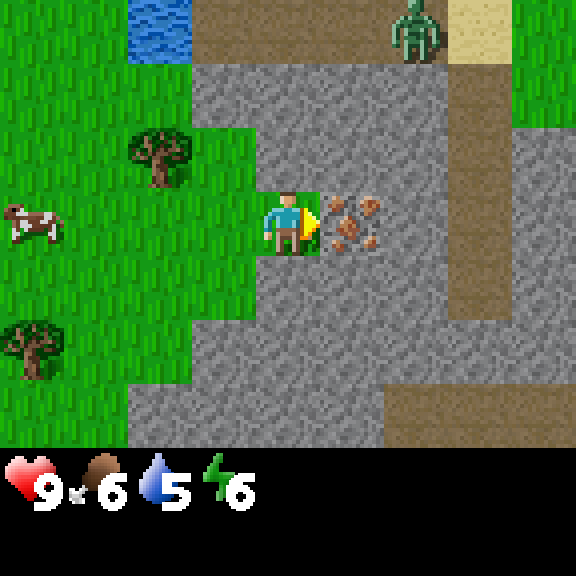

In [9]:
img = Image.fromarray(np.array(obs).astype(np.uint8))
img

In [10]:
info["text_render"]

'Map: \ngrass -4, 3 grass -3, 3 water -2, 3 path -1, 3 path 0, 3 path 1, 3 zombie 2, 3 sand 3, 3 grass 4, 3\ngrass -4, 2 grass -3, 2 grass -2, 2 stone -1, 2 stone 0, 2 stone 1, 2 stone 2, 2 path 3, 2 grass 4, 2\ngrass -4, 1 grass -3, 1 tree -2, 1 grass -1, 1 stone 0, 1 stone 1, 1 stone 2, 1 path 3, 1 stone 4, 1\ncow -4, 0 grass -3, 0 grass -2, 0 grass -1, 0 agent 0, 0 iron 1, 0 stone 2, 0 path 3, 0 stone 4, 0\ngrass -4, -1 grass -3, -1 grass -2, -1 grass -1, -1 stone 0, -1 stone 1, -1 stone 2, -1 path 3, -1 stone 4, -1\ntree -4, -2 grass -3, -2 grass -2, -2 stone -1, -2 stone 0, -2 stone 1, -2 stone 2, -2 stone 3, -2 stone 4, -2\ngrass -4, -3 grass -3, -3 stone -2, -3 stone -1, -3 stone 0, -3 stone 1, -3 path 2, -3 path 3, -3 path 4, -3\nInventory: ; \n \nPlayer Direction: Right'

In [ ]:
print(info["text_render"])

In [ ]:
# Предполагается, что ваша функция находится здесь
# Замените на правильный импорт
from agent_system.environments.env_package.craftext.projection import craftext_projection 

# Пример ответа модели из ваших логов
sample_response_1 = """To gather a sapling, you need to use a tool that can break wood. The available tools are a wood pickaxe, a stone pickaxe, and an iron pickaxe. Since you have no pickaxes, you will need to make one first.

The action you should take is:
<action>make wood pickaxe</action>
This will allow you to gather a sapling."""

# Пример ответа, где может быть ошибка (например, с переводом строки)
sample_response_2 = """<action>
left
</action>"""

# Пример ответа без тегов
sample_response_3 = "I will go left."


# --- НАЧАЛО ТЕСТА ---

# Создайте экземпляр вашего проектора
# Возможно, ему нужны какие-то параметры при инициализации
action_projector = craftext_projection

# Подаем на вход список ответов, как в коде
text_actions = [sample_response_1, sample_response_2, sample_response_3]

# Вызываем функцию
action_ids, valids = action_projector(text_actions) # или projector.projection_f(...)

# Печатаем результат
print(f"Input 1: '{sample_response_1[:50]}...'")
print(f"  -> action_id: {action_ids[0]}, is_valid: {valids[0]}")
print("-" * 20)

print(f"Input 2: '{sample_response_2[:50]}...'")
print(f"  -> action_id: {action_ids[1]}, is_valid: {valids[1]}")
print("-" * 20)

print(f"Input 3: '{sample_response_3[:50]}...'")
print(f"  -> action_id: {action_ids[2]}, is_valid: {valids[2]}")